# 参考mnist_conv-keras实现针对cifar10的alexNet卷积模型


#### 链接: https://pan.baidu.com/s/1LcCPcK9DgLS3W_DUPZS8kQ 提取码: 5vwz
### 解压放到 ~/.keras/datasets/

## tar zxvf cifar***.tar.zip

## 准备数据

In [13]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from PIL import Image
import pylab

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [14]:
def cifar10_dataset(batch_size=100):
    # Match the old tf flow: normalize to [0,1], train use first 20000 samples
    train_ds_raw = datasets.CIFAR10(root='./cifar10/', train=True, download=True)
    test_ds_raw = datasets.CIFAR10(root='./cifar10/', train=False, download=True)

    x = torch.tensor(np.array(train_ds_raw.data), dtype=torch.float32) / 255.0
    y = torch.tensor(np.array(train_ds_raw.targets), dtype=torch.long)
    x_test = torch.tensor(np.array(test_ds_raw.data), dtype=torch.float32) / 255.0
    y_test = torch.tensor(np.array(test_ds_raw.targets), dtype=torch.long)

    # take(20000)
    x = x[:20000]
    y = y[:20000]

    train_tensor = TensorDataset(x.permute(0, 3, 1, 2), y)
    test_tensor = TensorDataset(x_test.permute(0, 3, 1, 2), y_test)

    ds = DataLoader(train_tensor, batch_size=batch_size, shuffle=True)
    test_ds = DataLoader(test_tensor, batch_size=20000, shuffle=False)
    return ds, test_ds


## 建立模型

In [15]:
class myConvModel(nn.Module):
    # Same structure as your TF code
    def __init__(self):
        super().__init__()
        self.l1_conv = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=5, padding=2)
        self.l2_conv = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flat = nn.Flatten()
        self.dense1 = nn.Linear(64 * 8 * 8, 100)
        self.dense2 = nn.Linear(100, 10)

    def _forward_logits(self, x):
        h1 = F.relu(self.l1_conv(x))
        h1_pool = self.pool(h1)
        h2 = F.relu(self.l2_conv(h1_pool))
        h2_pool = self.pool(h2)
        flat_h = self.flat(h2_pool)
        dense1 = torch.tanh(self.dense1(flat_h))
        logits = self.dense2(dense1)
        return logits

    def forward(self, x):
        logits = self._forward_logits(x)
        probs = torch.softmax(logits, dim=-1)
        return probs

    def getL1_feature_map(self, x):
        # Match your TF reference: return l1_conv output directly (no relu)
        if isinstance(x, np.ndarray):
            x = torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2)
        with torch.no_grad():
            h1 = self.l1_conv(x.to(device))
        return h1.permute(0, 2, 3, 1).cpu().numpy()

    def getL2_feature_map(self, x):
        # Match your TF reference exactly: l1_conv -> pool -> l2_conv (no relu in feature map path)
        if isinstance(x, np.ndarray):
            x = torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2)
        with torch.no_grad():
            h1 = self.l1_conv(x.to(device))
            h1_pool = self.pool(h1)
            h2 = self.l2_conv(h1_pool)
        return h2.permute(0, 2, 3, 1).cpu().numpy()


model = myConvModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


## 编译， fit以及evaluate

In [16]:
train_ds, test_ds = cifar10_dataset()
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    model.train()
    total_loss, total_correct, total = 0.0, 0.0, 0

    for x, y in train_ds:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model._forward_logits(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == y).float().sum().item()
        total += bs

    model.eval()
    with torch.no_grad():
        for x, y in test_ds:
            x, y = x.to(device), y.to(device)
            logits = model._forward_logits(x)
            test_loss = criterion(logits, y).item()
            test_acc = (logits.argmax(dim=1) == y).float().mean().item()

    print(f'Epoch {epoch + 1}/10 - loss: {total_loss/total:.4f} - accuracy: {total_correct/total:.4f} - val_loss: {test_loss:.4f} - val_accuracy: {test_acc:.4f}')


Epoch 1/10 - loss: 1.7779 - accuracy: 0.3529 - val_loss: 1.5228 - val_accuracy: 0.4432
Epoch 2/10 - loss: 1.4147 - accuracy: 0.4854 - val_loss: 1.3302 - val_accuracy: 0.5199
Epoch 3/10 - loss: 1.2631 - accuracy: 0.5470 - val_loss: 1.2526 - val_accuracy: 0.5494
Epoch 4/10 - loss: 1.1347 - accuracy: 0.5988 - val_loss: 1.1437 - val_accuracy: 0.5946
Epoch 5/10 - loss: 1.0588 - accuracy: 0.6232 - val_loss: 1.1392 - val_accuracy: 0.5926
Epoch 6/10 - loss: 0.9551 - accuracy: 0.6643 - val_loss: 1.1555 - val_accuracy: 0.5929
Epoch 7/10 - loss: 0.8814 - accuracy: 0.6915 - val_loss: 1.0781 - val_accuracy: 0.6192
Epoch 8/10 - loss: 0.7884 - accuracy: 0.7239 - val_loss: 1.0834 - val_accuracy: 0.6300
Epoch 9/10 - loss: 0.7234 - accuracy: 0.7472 - val_loss: 1.0691 - val_accuracy: 0.6331
Epoch 10/10 - loss: 0.6550 - accuracy: 0.7774 - val_loss: 1.0640 - val_accuracy: 0.6392


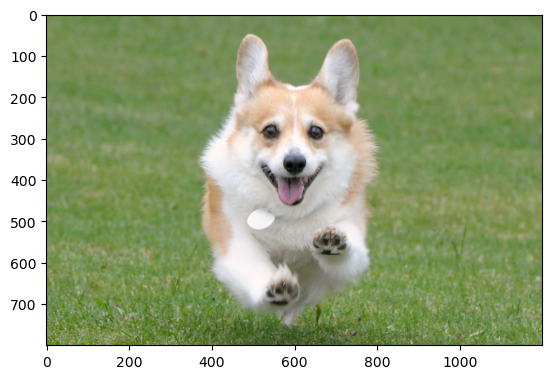

In [17]:
import numpy
import pylab
from PIL import Image
import numpy as np

ds, test_ds = cifar10_dataset()

for i in test_ds:
    test_batch = i[0][:1, :, :]
    break
img = Image.open(open('corgi.jpg', 'rb'))
img = numpy.asarray(img, dtype='float32') / 256.
# print(img.shape)
img = np.expand_dims(img, axis=0)

# img = test_batch
img_out = model.getL2_feature_map(img)
pylab.imshow(img[0, :, :, :])


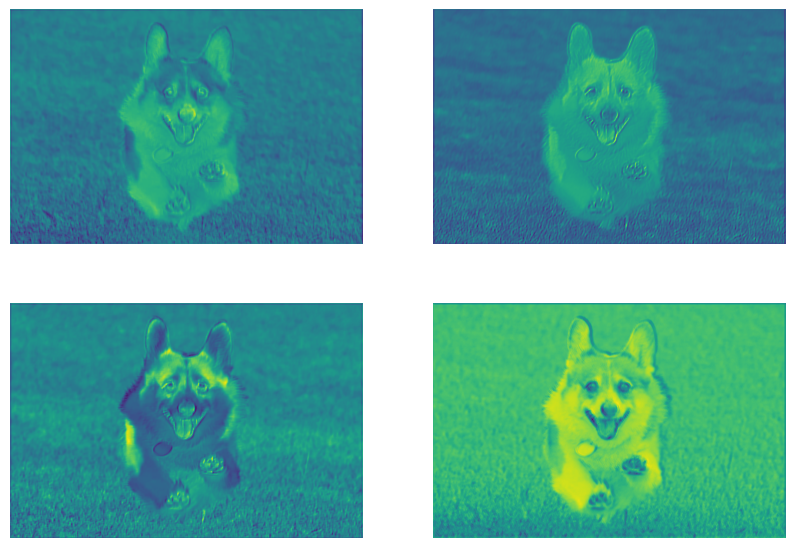

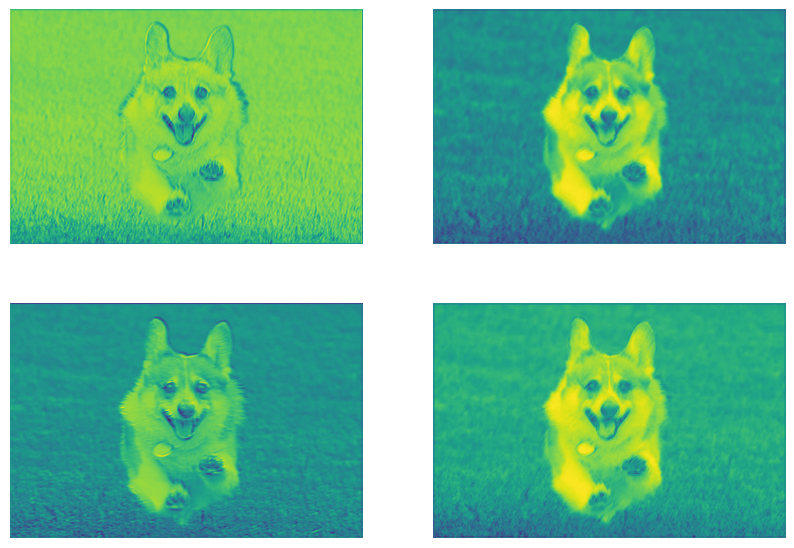

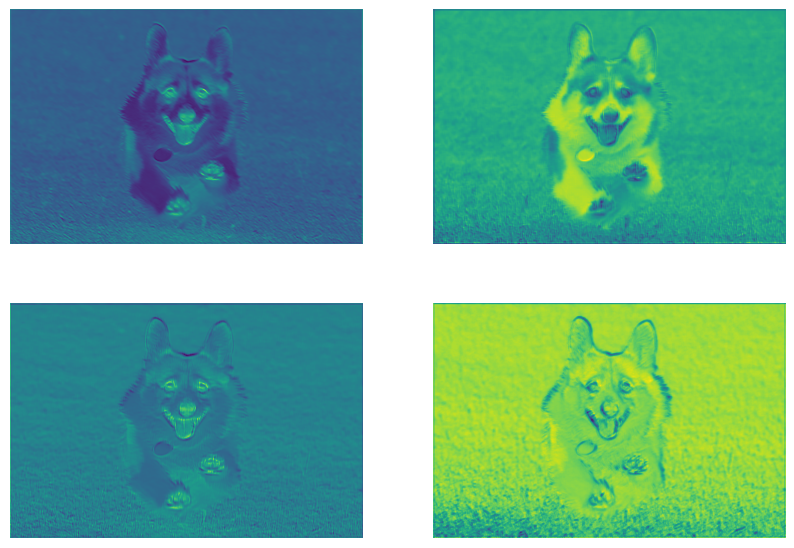

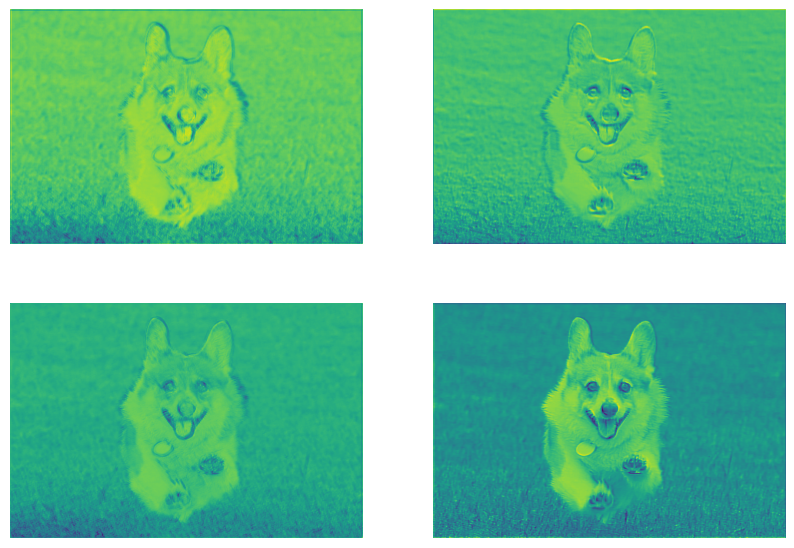

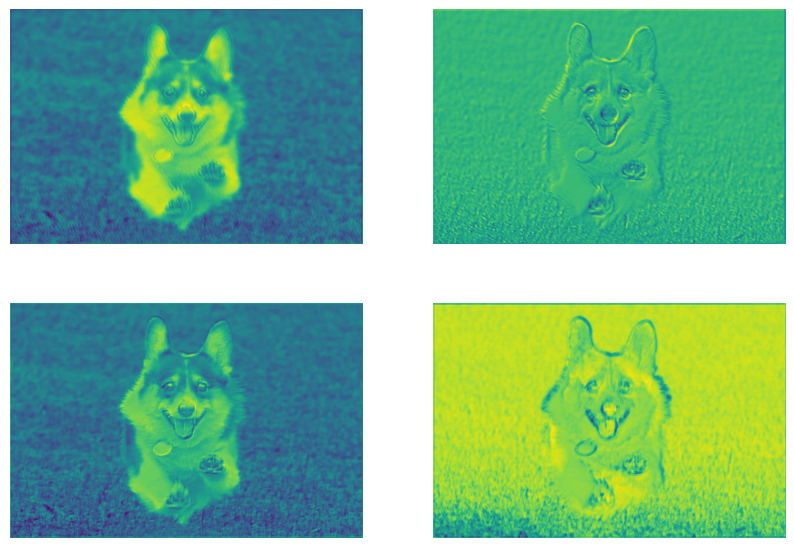

In [18]:
pylab.figure(figsize=(10,7))
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 0])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 1])
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 2])
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 3])
pylab.show()

pylab.figure(figsize=(10,7))
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 4])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 5])
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 6])
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 7])
pylab.show()

pylab.figure(figsize=(10,7))
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 8])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 9])
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 10])
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 11])
pylab.show()

pylab.figure(figsize=(10,7))
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 12])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 13])
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 14])
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 15])
pylab.show()


pylab.figure(figsize=(10,7))
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 16])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 17])
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 18])
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 19])
pylab.show()
